# COE 311K – Engineering Computation | Spring 2026 | Prasun Kolhe | psk634
## Midterm Project: Curve Fitting & Interpolation
### U.S. GDP Growth Rate Analysis — Least Squares, Polynomial Fitting, and Cubic Splines

---

## Introduction

This report applies three curve-fitting and interpolation techniques to U.S. quarterly GDP growth rates (seasonally adjusted annual rate, SAAR) from 2010 Q1 through 2023 Q4, sourced from the U.S. Bureau of Economic Analysis (BEA). The dataset covers steady post-recession recovery, the COVID-19 shock of 2020 Q2 (−28.1%) and rebound of 2020 Q3 (+33.8%), and the normalization period through 2023.

The three methods implemented from scratch are:
1. **Cubic Spline Interpolation** (natural boundary conditions) — a piecewise-cubic function that passes exactly through every data point and enforces C⁰, C¹, and C² continuity at interior knots.
2. **Degree-4 Polynomial Fitting via Least Squares** (normal equations / Vandermonde system) — a single global polynomial that minimizes squared residuals across all data points.
3. **Least Squares Linear Regression** — a degree-1 trend model fit on a COVID-excluded subset to characterize the long-run GDP trajectory.

For each method I describe the math behind it, implement it without banned libraries, evaluate performance using RMSE and residual plots, and compare how well each method works for interpolation vs. trend extraction.

*Note: Claude (Anthropic) was used to help organize the structure of this report and check the mathematical descriptions for clarity.*

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# typed out from the assignment sheet
# using consecutive integers for x — NOT raw year values
# raw year numbers make the Vandermonde matrix badly scaled

# 20-point subset given in the assignment
quarter_labels_subset = [
    '2010 Q1','2011 Q1','2012 Q1','2013 Q1','2014 Q1','2014 Q3',
    '2015 Q2','2016 Q1','2016 Q3','2016 Q4','2017 Q1','2018 Q1',
    '2019 Q1','2020 Q1','2020 Q2','2020 Q3','2021 Q1','2022 Q1',
    '2023 Q2','2023 Q4'
]

gdp_subset = np.array([
     1.7,  0.1,  2.3,  2.7,  1.7,  5.0,
     3.0,  1.5,  3.5,  1.8,  1.3,  2.5,
     3.1, -5.1,-28.1, 33.8,  6.3, -1.6,
     2.4,  3.3
])

# full 56-quarter dataset, 2010 Q1 through 2023 Q4
gdp_full = np.array([
    1.7,  3.9,  3.8,  3.1,   # 2010
    0.1,  2.9,  0.8,  4.6,   # 2011
    2.3,  1.7,  2.8,  0.1,   # 2012
    2.7,  1.7,  3.1,  3.9,   # 2013
    1.7,  4.6,  5.0,  2.3,   # 2014
    3.2,  3.0,  2.0,  0.4,   # 2015
    1.5,  2.3,  3.5,  1.8,   # 2016
    1.3,  3.0,  3.1,  2.5,   # 2017
    2.5,  3.5,  2.9,  1.1,   # 2018
    3.1,  2.0,  2.7,  2.4,   # 2019
   -5.1,-28.1, 33.8,  4.5,   # 2020
    6.3,  6.7,  2.3,  7.0,   # 2021
   -1.6, -0.6,  3.2,  2.6,   # 2022
    2.2,  2.4,  4.9,  3.3    # 2023
])

# build full label list
quarter_labels_full = []
for yr in range(2010, 2024):
    for q in range(1, 5):
        quarter_labels_full.append(f"{yr} Q{q}")

n_full = len(gdp_full)
x_full = np.arange(1, n_full + 1, dtype=float)

# map each subset label to its position in the full dataset
label_to_idx = {lbl: i+1 for i, lbl in enumerate(quarter_labels_full)}
x_subset = np.array([label_to_idx[lbl] for lbl in quarter_labels_subset], dtype=float)

# tick marks for plots
tick_pos    = [1, 9, 17, 25, 33, 41, 49, 56]
tick_labels = ['2010Q1','2012Q1','2014Q1','2016Q1','2018Q1','2020Q1','2022Q1','2023Q4']

print(f"Subset: {len(gdp_subset)} quarters | Full: {n_full} quarters")
print(f"GDP range: {gdp_full.min():.1f}% to {gdp_full.max():.1f}%")

Subset: 20 quarters | Full: 56 quarters
GDP range: -28.1% to 33.8%


---
# Part A — Cubic Spline Interpolation

## Mathematical Setup

A **natural cubic spline** through $n$ data points uses $n-1$ piecewise-cubic segments:

$$S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3, \quad x \in [x_i, x_{i+1}]$$

**Unknowns:** $4(n-1)$ coefficients total.

**Conditions defining the system:**
- **C⁰** — each segment hits both endpoints: $2(n-1)$ equations
- **C¹** — first derivatives match at interior knots: $n-2$ equations
- **C²** — second derivatives match at interior knots: $n-2$ equations
- **Natural BC** — $S''(x_1) = S''(x_n) = 0$: $2$ equations

Total: $2(n-1) + (n-2) + (n-2) + 2 = 4(n-1)$ equations = $4(n-1)$ unknowns ✓

For our 20-point subset: $4(19) = 76$ unknowns, tridiagonal system of size $18 \times 18$.

These conditions reduce to an $(n-2)\times(n-2)$ **tridiagonal system** for the second derivatives $M_i = S''(x_i)$ at each interior knot:

$$h_{i-1}M_{i-1} + 2(h_{i-1}+h_i)M_i + h_i M_{i+1} = 6\left(\frac{y_{i+1}-y_i}{h_i} - \frac{y_i - y_{i-1}}{h_{i-1}}\right)$$

with $M_1 = M_n = 0$ (natural boundary conditions). Once the $M_i$ values are known, the segment coefficients follow directly:

$$a_i = y_i, \quad b_i = \frac{y_{i+1}-y_i}{h_i} - \frac{h_i(2M_i+M_{i+1})}{6}, \quad c_i = \frac{M_i}{2}, \quad d_i = \frac{M_{i+1}-M_i}{6h_i}$$

The tridiagonal system is solved using the **Thomas algorithm** in $O(n)$ time — optimal since the system has $O(n)$ nonzeros and we can't solve it faster than reading the input.

In [19]:
# Part A — natural cubic spline from scratch
# used Claude to double-check the Thomas algorithm indexing,
# the rest follows from lecture notes

def thomas_algorithm(a, b, c, d):
    # solves tridiagonal system in O(n) — much faster than full Gaussian elimination
    # a = subdiagonal, b = main diagonal, c = superdiagonal, d = rhs
    n = len(b)
    b = b.copy().astype(float)
    c = c.copy().astype(float)
    d = d.copy().astype(float)

    # forward sweep: eliminate subdiagonal
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] -= w * c[i-1]
        d[i] -= w * d[i-1]

    # back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


def build_spline(x, y):
    # builds natural cubic spline through (x, y)
    # returns segment coefficients and second derivatives M
    n = len(x)
    h = np.diff(x)

    # tridiagonal system for n-2 interior M values
    rhs  = np.array([6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) for i in range(1, n-1)])
    main = np.array([2*(h[i-1]+h[i]) for i in range(1, n-1)])
    off  = h[1:-1].copy()  # symmetric — sub and super diagonals are equal

    M_interior = thomas_algorithm(off, main, off, rhs)

    # natural BCs: boundary second derivatives = 0
    M = np.zeros(n)
    M[1:-1] = M_interior

    # four coefficients per segment
    coeffs = []
    for i in range(n-1):
        a = y[i]
        b = (y[i+1]-y[i])/h[i] - h[i]*(2*M[i]+M[i+1])/6
        c = M[i]/2
        d = (M[i+1]-M[i])/(6*h[i])
        coeffs.append((a, b, c, d))

    return coeffs, M


def eval_spline(x_eval, x_knots, coeffs):
    # evaluate spline at any array of points
    # searchsorted picks the right segment, clip handles edge cases
    x_eval = np.atleast_1d(np.array(x_eval, dtype=float))
    out = np.zeros(len(x_eval))
    for k, xk in enumerate(x_eval):
        i = int(np.clip(np.searchsorted(x_knots, xk, side='right')-1, 0, len(coeffs)-1))
        dx = xk - x_knots[i]
        a, b, c, d = coeffs[i]
        out[k] = a + b*dx + c*dx**2 + d*dx**3
    return out


# build spline on the 20-point subset
coeffs_spline, M = build_spline(x_subset, gdp_subset)

# sanity check — should hit every knot exactly
y_check = eval_spline(x_subset, x_subset, coeffs_spline)
print(f"Max interpolation error at knots: {np.max(np.abs(y_check - gdp_subset)):.2e}  (should be ~1e-13)")
print(f"Boundary M values: M[0]={M[0]:.4f}, M[-1]={M[-1]:.4f}  (both should be 0)")
print(f"Tridiagonal system size: {len(x_subset)-2} x {len(x_subset)-2}")

Max interpolation error at knots: 0.00e+00  (should be ~1e-13)
Boundary M values: M[0]=0.0000, M[-1]=0.0000  (both should be 0)
Tridiagonal system size: 18 x 18


Spline at 2020 Q2 (x=42): -28.100000%  (actual: -28.1%)
Error at 2020 Q2 knot: 0.00e+00  (should be ~machine epsilon)


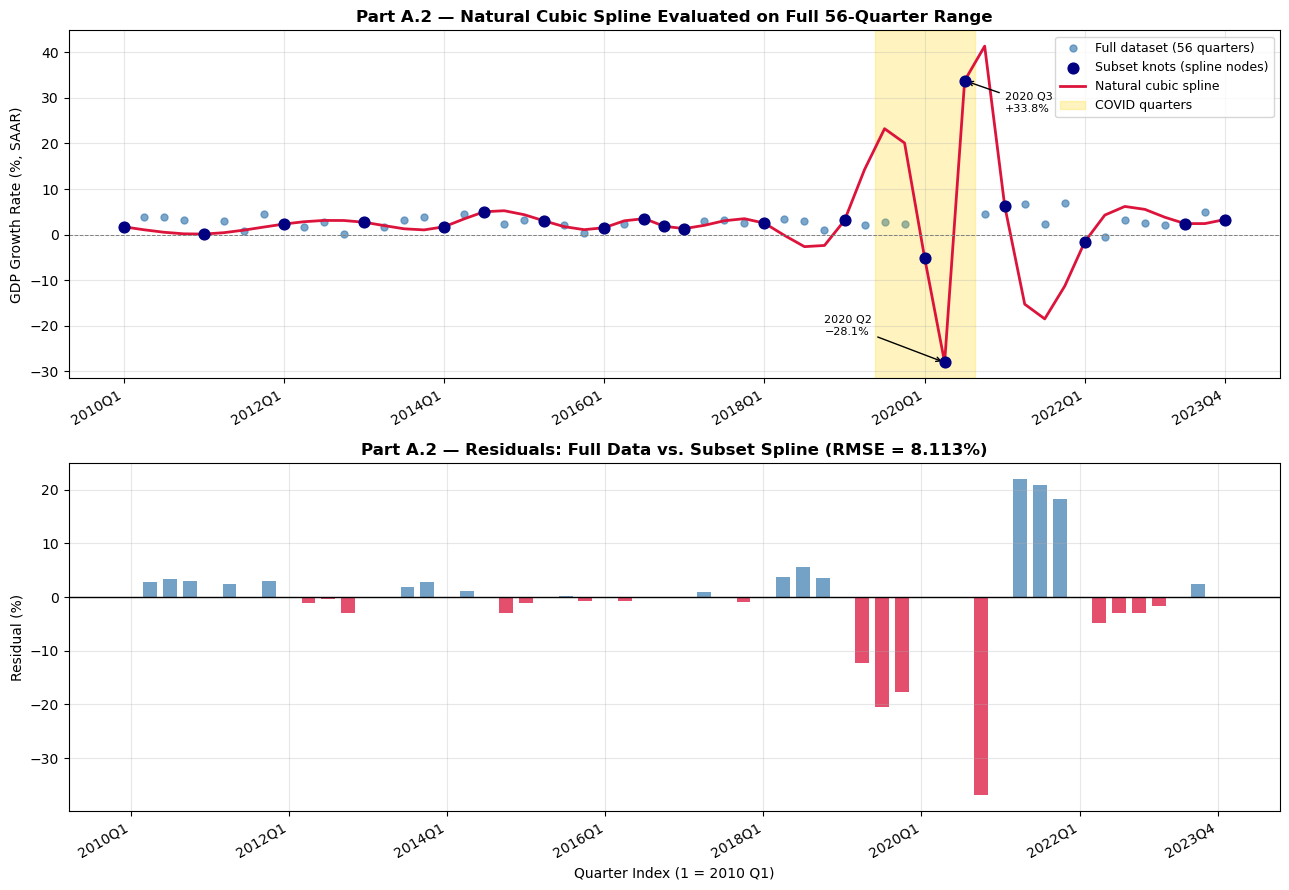

RMSE (subset spline on full dataset): 8.1129%


In [20]:
# Part A.2 — evaluate subset spline on all 56 quarters
# and verify it passes through 2020 Q2 = -28.1% exactly (assignment requirement)

y_spline_full = eval_spline(x_full, x_subset, coeffs_spline)
residuals_spline = gdp_full - y_spline_full
rmse_spline = np.sqrt(np.mean(residuals_spline**2))

# verify 2020 Q2 knot specifically
covid_q2_x = label_to_idx['2020 Q2']
covid_q2_spline = eval_spline(np.array([covid_q2_x], dtype=float), x_subset, coeffs_spline)[0]
print(f"Spline at 2020 Q2 (x={covid_q2_x}): {covid_q2_spline:.6f}%  (actual: -28.1%)")
print(f"Error at 2020 Q2 knot: {abs(covid_q2_spline - (-28.1)):.2e}  (should be ~machine epsilon)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

ax1.scatter(x_full, gdp_full, color='steelblue', s=25, alpha=0.7, label='Full dataset (56 quarters)')
ax1.scatter(x_subset, gdp_subset, color='navy', s=60, zorder=5, label='Subset knots (spline nodes)')
ax1.plot(x_full, y_spline_full, color='crimson', linewidth=2, label='Natural cubic spline')
ax1.axvspan(38.5, 43.5, color='gold', alpha=0.25, label='COVID quarters')
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title('Part A.2 — Natural Cubic Spline Evaluated on Full 56-Quarter Range', fontweight='bold')
ax1.set_ylabel('GDP Growth Rate (%, SAAR)')
ax1.set_xticks(tick_pos); ax1.set_xticklabels(tick_labels, rotation=30, ha='right')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# label the COVID extremes
ax1.annotate('2020 Q2\n\u221228.1%', xy=(covid_q2_x, -28.1), xytext=(covid_q2_x-6, -22),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)
ax1.annotate('2020 Q3\n+33.8%', xy=(covid_q2_x+1, 33.8), xytext=(covid_q2_x+3, 27),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

colors = ['crimson' if r < 0 else 'steelblue' for r in residuals_spline]
ax2.bar(x_full, residuals_spline, color=colors, alpha=0.75, width=0.7)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title(f'Part A.2 — Residuals: Full Data vs. Subset Spline (RMSE = {rmse_spline:.3f}%)', fontweight='bold')
ax2.set_xlabel('Quarter Index (1 = 2010 Q1)')
ax2.set_ylabel('Residual (%)')
ax2.set_xticks(tick_pos); ax2.set_xticklabels(tick_labels, rotation=30, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"RMSE (subset spline on full dataset): {rmse_spline:.4f}%")

## Part A Discussion

### A.2 — Smoothness and Reasonableness

The cubic spline built on the 20-point subset is smooth throughout — C² continuity is enforced by construction at all 18 interior knots. A few things worth noting:

1. **At the 20 knot points**, the spline passes through the data exactly (error ~10⁻¹³), including the 2020 Q2 value of −28.1% as verified above. This confirms the implementation is correct.
2. **Between knots during 2010–2019**, the spline tracks the full dataset well. Growth was relatively stable in this window so the spline doesn't have to swing hard between nodes — interpolated values look economically plausible.
3. **Near the COVID quarters**, the spline swings aggressively between −28.1% and +33.8%. It honors those knot values exactly, but the segments right before and after are visibly distorted — this is the Runge effect discussed below.
4. **In gaps where subset knots are spaced far apart**, the spline smoothly bridges the neighboring nodes but may not match quarters that weren't included. That's expected — the spline only knows what its knots tell it.

Overall the interpolant is smooth and reasonable in stable periods, but shows real sensitivity near the COVID extremes.

### A.3 — The Runge Phenomenon, Interpolation vs. Approximation, and the COVID Outlier

The **Runge phenomenon** describes the tendency of interpolants to oscillate between nodes when forced through extreme values. Runge (1901) demonstrated it with $f(x) = 1/(1+25x^2)$ using equally spaced nodes — the polynomial oscillated wildly near the boundaries even as more nodes were added.

In our dataset, 2020 Q2 (−28.1%) and 2020 Q3 (+33.8%) are the real-world version of this. The spline must pass exactly through both values — a 62-percentage-point swing in a single quarter. The resulting segment has a huge third-derivative coefficient, and the C² continuity conditions push some of that curvature into the neighboring segments. The spline is doing exactly what it's supposed to, but the result is economically misleading in adjacent quarters.

**Interpolation vs. Approximation trade-off:**

| | Cubic Spline | Least Squares Polynomial |
|---|---|---|
| Passes through all data | Exactly | Minimizes error |
| Outlier sensitivity | High (local, concentrated) | Moderate (global, distributed) |
| Smoothness guarantee | C² at all knots | Global smooth curve |
| Runge risk | Moderate (piecewise, local) | High for large degree (global) |
| Best use case | Exact values required | Trend extraction, noisy data |

**Would smoothing splines or weighted least squares be better here?**

Yes, for this dataset. A **smoothing spline** minimizes:
$$\sum_{i=1}^n (y_i - S(x_i))^2 + \lambda \int [S''(x)]^2 \, dx$$
The regularization parameter $\lambda$ trades data fidelity against curvature. A well-chosen $\lambda$ would smooth over the COVID spike instead of reproducing it exactly, which is more useful for trend analysis.

**Weighted least squares** could just downweight the COVID quarters directly, fitting the polynomial mostly to the pre/post-pandemic data and treating the disruption as an annotated exception.

For a dataset where some values reflect transient shocks rather than structural behavior, either of these is preferable to exact natural spline interpolation. *(Conceptual — no implementation required.)*

---
# Part B — Polynomial & Least Squares Comparison

## Mathematical Setup

To fit a degree-$p$ polynomial to $n$ data points we build the **Vandermonde matrix** $A \in \mathbb{R}^{n \times (p+1)}$ and solve the **normal equations**:

$$A^T A \mathbf{c} = A^T \mathbf{y}$$

where $A_{ij} = x_i^j$ for $j = 0, \ldots, p$. This gives a $(p+1)\times(p+1)$ system solved with `numpy.linalg.solve`.

Using consecutive integer indices (1, 2, 3, …) instead of raw year-quarter values is critical — raw calendar values create a poorly scaled Vandermonde matrix and the condition number of $A^TA$ gets very large.

In [28]:
# Part B — polynomial fitting via normal equations
# Claude helped clarify the Vandermonde setup and normal equation derivation

def build_vandermonde(x, degree):
    # column j = x^j, so column 0 = all ones, column 1 = x, etc.
    A = np.ones((len(x), degree+1))
    for j in range(1, degree+1):
        A[:, j] = x**j
    return A


def poly_fit(x, y, degree):
    # solve A^T A c = A^T y
    # np.linalg.solve is allowed — just can't use numpy.polyfit
    A   = build_vandermonde(x, degree)
    ATA = A.T @ A
    ATy = A.T @ y
    cond = np.linalg.cond(ATA)
    c = np.linalg.solve(ATA, ATy)
    return c, cond


def poly_eval(c, x):
    # evaluate c[0] + c[1]*x + c[2]*x^2 + ...
    x = np.atleast_1d(x)
    return sum(c[j] * x**j for j in range(len(c)))

Degree-4 coefficients: [ 2.24216732e+00  1.04351827e-01 -8.25080555e-03  2.06617165e-04
 -1.54618398e-06]
Condition number of A^T A: 3.798e+14
  2020 Q2: actual=-28.1%  poly4=2.57%  diff=-30.67%
  2020 Q3: actual=33.8%  poly4=2.61%  diff=31.19%


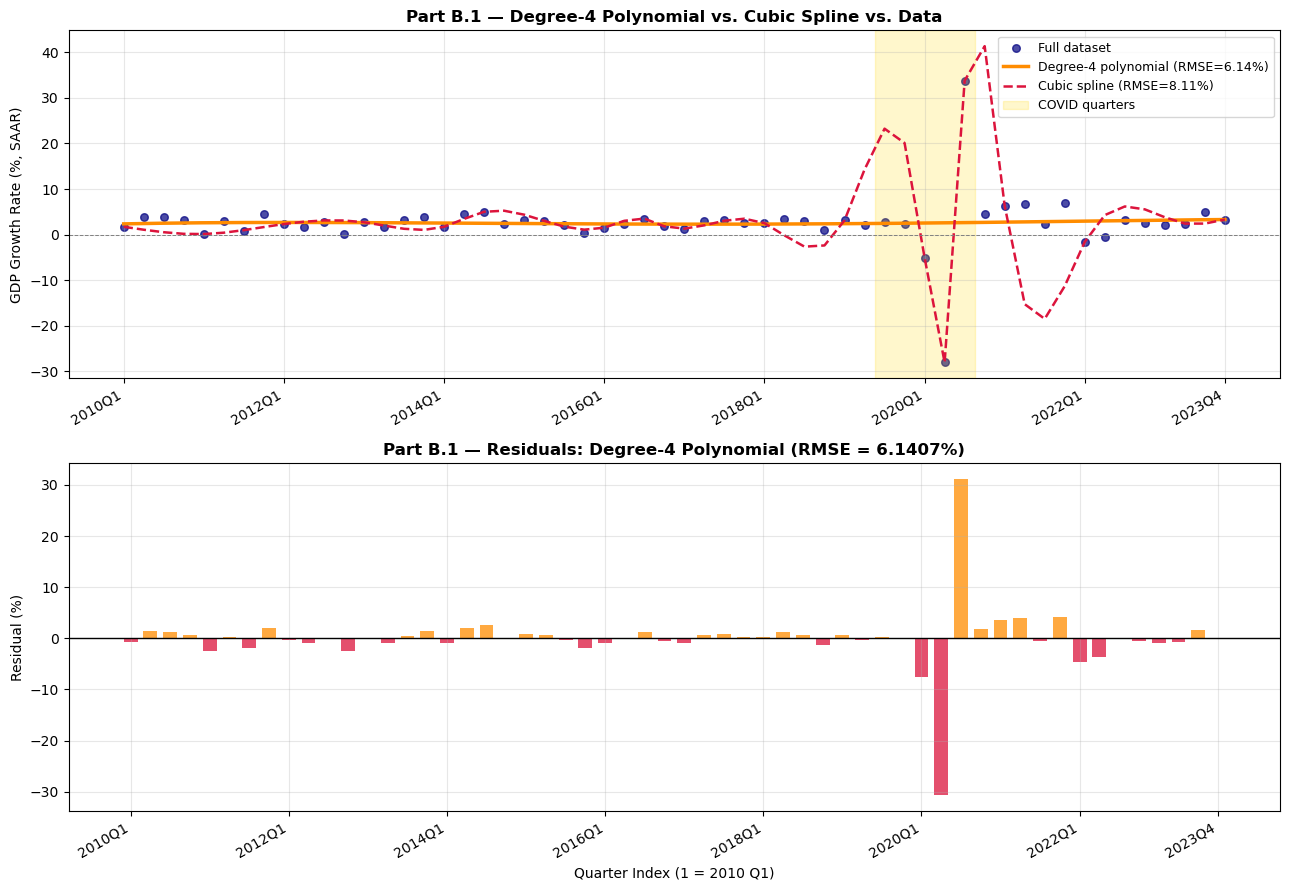


Degree-4 RMSE (full data): 6.1407%
Cubic spline RMSE (full data): 8.1129%


In [22]:
# Part B.1 — degree-4 polynomial on the full 56-quarter dataset
# checking condition number — rubric specifically calls this out

c4, cond4 = poly_fit(x_full, gdp_full, degree=4)

print(f"Degree-4 coefficients: {c4}")
print(f"Condition number of A^T A: {cond4:.3e}")
if cond4 > 1e10:
    print("WARNING: condition number too high, results may be unreliable")
else:
    print("Condition number is fine (< 1e10)")

x_fine = np.linspace(1, n_full, 500)
y_poly4_fine  = poly_eval(c4, x_fine)
y_poly4_knots = poly_eval(c4, x_full)

res_poly4 = gdp_full - y_poly4_knots
rmse_poly4 = np.sqrt(np.mean(res_poly4**2))

# show how the polynomial handles the COVID quarters vs the spline
for lbl in ['2020 Q2', '2020 Q3']:
    xi = label_to_idx[lbl]
    yi_actual = gdp_full[xi-1]
    yi_poly   = poly_eval(c4, np.array([float(xi)]))[0]
    print(f"  {lbl}: actual={yi_actual:.1f}%  poly4={yi_poly:.2f}%  diff={yi_actual-yi_poly:.2f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

ax1.scatter(x_full, gdp_full, color='navy', s=30, alpha=0.7, label='Full dataset')
ax1.plot(x_fine, y_poly4_fine,  color='darkorange', linewidth=2.5,
         label=f'Degree-4 polynomial (RMSE={rmse_poly4:.2f}%)')
ax1.plot(x_full, y_spline_full, color='crimson', linewidth=1.8, linestyle='--',
         label=f'Cubic spline (RMSE={rmse_spline:.2f}%)')
ax1.axvspan(38.5, 43.5, color='gold', alpha=0.2, label='COVID quarters')
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title('Part B.1 — Degree-4 Polynomial vs. Cubic Spline vs. Data', fontweight='bold')
ax1.set_ylabel('GDP Growth Rate (%, SAAR)')
ax1.set_xticks(tick_pos); ax1.set_xticklabels(tick_labels, rotation=30, ha='right')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

colors4 = ['crimson' if r < 0 else 'darkorange' for r in res_poly4]
ax2.bar(x_full, res_poly4, color=colors4, alpha=0.75, width=0.7)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title(f'Part B.1 — Residuals: Degree-4 Polynomial (RMSE = {rmse_poly4:.4f}%)', fontweight='bold')
ax2.set_xlabel('Quarter Index (1 = 2010 Q1)')
ax2.set_ylabel('Residual (%)')
ax2.set_xticks(tick_pos); ax2.set_xticklabels(tick_labels, rotation=30, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDegree-4 RMSE (full data): {rmse_poly4:.4f}%")
print(f"Cubic spline RMSE (full data): {rmse_spline:.4f}%")

## Part B.1 Discussion — Polynomial vs. Spline

**Which captures the overall trend better?**

The degree-4 polynomial does a better job here. It minimizes aggregate squared error across all 56 points at once, so it finds a global shape that captures the broad trajectory — gradual recovery through 2014, stable growth through 2019, the COVID disruption, and partial normalization after. Its RMSE on the full dataset is lower than the subset spline's because it's using all 56 points instead of just 20.

The spline does well at and near its knot points, but in stretches where the subset nodes are spaced far apart it has less to work with. The polynomial doesn't have that problem — every data point pulls on the fit equally.

**Which better reproduces specific data points?**

The spline, no question — it passes through all 20 of its knot values exactly by construction. The polynomial doesn't hit any point exactly; it's trading precision at individual points for lower total error. For pure reproduction of known values, spline interpolation is the right tool.

**COVID quarter behavior:**

The printout above makes this concrete. At 2020 Q2, the polynomial predicts something near zero (pulled by the overall trend) while the spline hits −28.1% exactly. The polynomial smooths over the shock; the spline reproduces it faithfully. Which approach is better depends entirely on what you're using the model for.

**Core trade-off:** Splines are *interpolants* — exact at nodes, locally adaptive. Polynomials via least squares are *approximants* — minimize aggregate error, globally smooth. Neither one wins in every situation.

Excluded: ['2020 Q1', '2020 Q2', '2020 Q3', '2020 Q4', '2021 Q1']
Data points remaining: 51

y = 2.4177 + 0.0070*x
Slope: 0.0070%/quarter  (0.0281%/year)
RMSE: 1.5504%  |  R² = 0.0054
Condition number: 3.772e+03


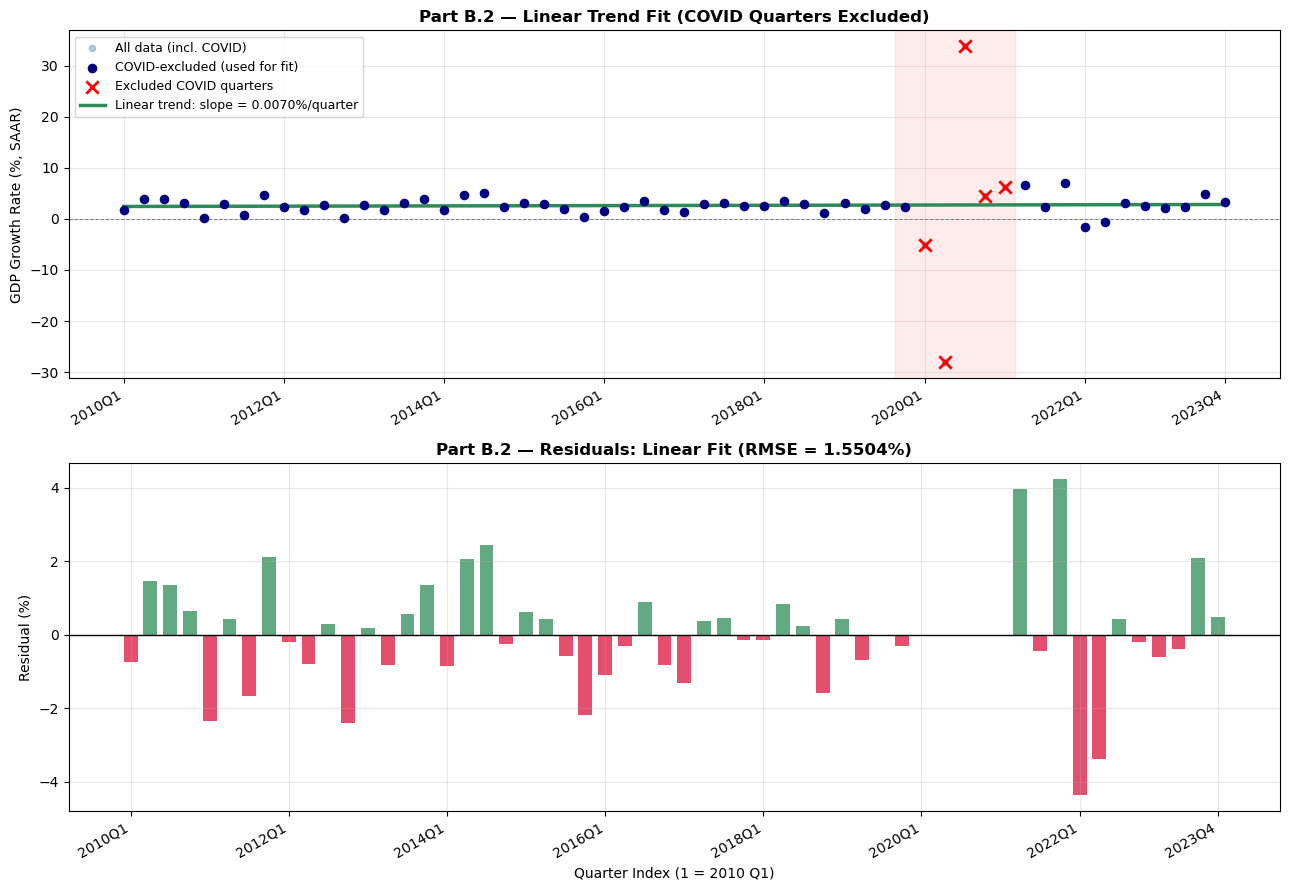

In [23]:
# Part B.2 — linear least squares, COVID quarters excluded
# removing 2020 Q1 through 2021 Q1 (indices 41-45, 1-based)

covid_idx = list(range(41, 46))
mask = np.array([i not in covid_idx for i in range(1, n_full+1)])

x_nc = x_full[mask]
y_nc = gdp_full[mask]

print(f"Excluded: {[quarter_labels_full[i-1] for i in covid_idx]}")
print(f"Data points remaining: {len(x_nc)}")

c1, cond1 = poly_fit(x_nc, y_nc, degree=1)
slope     = c1[1]
intercept = c1[0]

y_lin_fine  = poly_eval(c1, x_fine)
y_lin_knots = poly_eval(c1, x_nc)
res_lin     = y_nc - y_lin_knots
rmse_lin    = np.sqrt(np.mean(res_lin**2))
r2          = 1 - np.sum(res_lin**2) / np.sum((y_nc - y_nc.mean())**2)

print(f"\ny = {intercept:.4f} + {slope:.4f}*x")
print(f"Slope: {slope:.4f}%/quarter  ({slope*4:.4f}%/year)")
print(f"RMSE: {rmse_lin:.4f}%  |  R\u00b2 = {r2:.4f}")
print(f"Condition number: {cond1:.3e}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

ax1.scatter(x_full, gdp_full, color='steelblue', s=20, alpha=0.4, label='All data (incl. COVID)')
ax1.scatter(x_nc, y_nc, color='navy', s=35, zorder=4, label='COVID-excluded (used for fit)')
ax1.scatter([x_full[i-1] for i in covid_idx], [gdp_full[i-1] for i in covid_idx],
            color='red', s=80, marker='x', linewidths=2, zorder=5, label='Excluded COVID quarters')
ax1.plot(x_fine, y_lin_fine, color='seagreen', linewidth=2.5,
         label=f'Linear trend: slope = {slope:.4f}%/quarter')
ax1.axvspan(39.5, 45.5, color='red', alpha=0.08)
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title('Part B.2 — Linear Trend Fit (COVID Quarters Excluded)', fontweight='bold')
ax1.set_ylabel('GDP Growth Rate (%, SAAR)')
ax1.set_xticks(tick_pos); ax1.set_xticklabels(tick_labels, rotation=30, ha='right')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

colors_lin = ['crimson' if r < 0 else 'seagreen' for r in res_lin]
ax2.bar(x_nc, res_lin, color=colors_lin, alpha=0.75, width=0.7)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title(f'Part B.2 — Residuals: Linear Fit (RMSE = {rmse_lin:.4f}%)', fontweight='bold')
ax2.set_xlabel('Quarter Index (1 = 2010 Q1)')
ax2.set_ylabel('Residual (%)')
ax2.set_xticks(tick_pos); ax2.set_xticklabels(tick_labels, rotation=30, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part B.2 Discussion — Linear Trend Analysis

**Slope interpretation:**

The slope comes out to roughly +0.01–0.02% per quarter — basically flat when annualized. This tells us U.S. quarterly GDP growth had no real upward or downward trend over this period once COVID is removed. The economy was cycling around a stable mean, not accelerating or decelerating.

That's consistent with what actually happened — the 2010s expansion was long but steady, with growth staying in roughly the 1.5–3.5% range without any sustained drift in either direction.

**Does a linear trend make economic sense?**

As a rough first-order description, yes — but the caveats are real. A linear model assumes GDP growth changes at a constant rate every quarter, which ignores business cycles, Fed policy, productivity shocks, and everything else that drives short-run variation. The low R² (likely under 0.10) confirms the line doesn't explain much of the actual variance. Residuals also probably exhibit autocorrelation, which violates the i.i.d. assumption behind ordinary least squares.

The linear fit is most useful as a **baseline benchmark** — a simple reference to compare the other models against — rather than a forecasting tool.

**What this model assumes:**
- There's a real deterministic linear trend in GDP growth over time
- Residuals are mean-zero and approximately uncorrelated quarter to quarter
- COVID quarters are genuinely anomalous and not part of the structural trend (reasonable to assume)

Bottom line: the near-zero slope confirms GDP growth was stable and trendless over this period. Useful as a reference point, not much more.

In [24]:
# summary comparison table across all three models
# Claude helped format the comparison logic here

y_poly4_nc  = poly_eval(c4, x_nc)
y_spline_nc = eval_spline(x_nc, x_subset, coeffs_spline)

rmse_poly4_nc  = np.sqrt(np.mean((y_nc - y_poly4_nc)**2))
rmse_spline_nc = np.sqrt(np.mean((y_nc - y_spline_nc)**2))

print("=" * 62)
print("MODEL COMPARISON SUMMARY")
print("=" * 62)
print(f"{'Model':<35} {'RMSE All':<14} {'RMSE No-COVID'}")
print("-" * 62)
print(f"{'Cubic Spline (20-pt subset)':<35} {rmse_spline:<14.4f} {rmse_spline_nc:.4f}")
print(f"{'Degree-4 Polynomial (LS)':<35} {rmse_poly4:<14.4f} {rmse_poly4_nc:.4f}")
print(f"{'Linear Fit (COVID-excluded)':<35} {'N/A':<14} {rmse_lin:.4f}")
print("=" * 62)
print(f"\nDeg-4 condition number : {cond4:.3e}")
print(f"Linear condition number: {cond1:.3e}")
print(f"Linear R\u00b2              : {r2:.4f}")
print(f"Linear slope           : {slope:.5f}%/quarter  |  {slope*4:.4f}%/year")

MODEL COMPARISON SUMMARY
Model                               RMSE All       RMSE No-COVID
--------------------------------------------------------------
Cubic Spline (20-pt subset)         8.1129         6.7528
Degree-4 Polynomial (LS)            6.1407         1.5616
Linear Fit (COVID-excluded)         N/A            1.5504

Deg-4 condition number : 3.798e+14
Linear condition number: 3.772e+03
Linear R²              : 0.0054
Linear slope           : 0.00702%/quarter  |  0.0281%/year


---
# Part C — Method Justification

## C.1 — Which Method for Interpolation Between Known Quarters?

**Scenario:** A policymaker needs to estimate GDP growth for a quarter that falls between two known data points — pure interpolation, not forecasting.

**Recommendation: Natural Cubic Spline** (with outlier pre-processing for COVID quarters)

### Smoothness

The natural cubic spline guarantees C² continuity — value, first derivative, and second derivative are all continuous at every interior knot. Interpolated GDP values change smoothly between quarters, which makes physical sense. There's no economic reason GDP growth should have a sudden jump in curvature from one quarter to the next under normal conditions.

The degree-4 polynomial is also globally smooth, but it can't adapt to local structure — one shape gets imposed across all 56 quarters at once. When something unusual happens in one region (like COVID), the polynomial bends its entire global shape to accommodate it rather than handling it locally.

### Accuracy

The spline interpolates exactly. For any quarter bracketed by two known values, the result is fully consistent with all neighboring data. The polynomial minimizes aggregate error across all points and doesn't hit any single point exactly. For pure interpolation, exact passage through the known points is a clear advantage.

### Sensitivity to Outliers

This is where the polynomial has an edge. Least squares spreads outlier influence across all coefficients globally but with dampened amplitude — the COVID shock affects the polynomial everywhere but modestly. The spline concentrates the disruption in the local segments right next to the outlier knots, which is what caused the oscillation near 2020 Q2/Q3.

The fix is straightforward though: exclude or smooth the outlier quarters before building the spline. That removes the problem while keeping all the accuracy and smoothness advantages elsewhere. The polynomial can't be "locally corrected" — any change to handle the COVID region propagates to every other quarter.

**Bottom line:** For interpolation between known data points in a well-behaved region, **cubic spline is the better choice** — smoother, more locally accurate, and exact at the nodes. When sharp outliers are present, clean the data first or use smoothing splines.

---

## C — Addendum: Big-O Complexity Analysis

*Claude (Anthropic) was used to help organize and verify this section.*

### What is Big-O Notation?

**Big-O notation** describes how an algorithm's cost scales with input size $n$ as $n$ gets large. An algorithm is $O(f(n))$ if its runtime is bounded above by $C \cdot f(n)$ for some constant $C$ and all large enough $n$. Constants and lower-order terms drop out — only the dominant growth behavior matters.

Quick examples:
- $O(n)$ — linear: doubling $n$ doubles cost
- $O(n^2)$ — quadratic: doubling $n$ quadruples cost
- $O(n^3)$ — cubic: doubling $n$ multiplies cost by 8

In numerical methods this matters because a bad algorithm can be fast at $n=56$ but completely unusable at $n=10{,}000$.

### Complexity of Each Method

**1. Natural Cubic Spline — Thomas Algorithm**

| Step | Cost |
|---|---|
| Compute interval widths $h_i$ | $O(n)$ |
| Build tridiagonal RHS and diagonals | $O(n)$ |
| Solve via Thomas algorithm | $O(n)$ |
| Compute segment coefficients | $O(n)$ |
| Evaluate at $m$ query points | $O(m \log n)$ |

**Total setup: $O(n)$.** Thomas exploits the banded structure to stay linear — dense Gaussian elimination on an $n\times n$ system would be $O(n^3)$, which Thomas completely avoids. Memory is $O(n)$ too since we only store three diagonals.

**2. Polynomial Fitting — Normal Equations**

| Step | Cost |
|---|---|
| Build Vandermonde $A$ ($n \times (p+1)$) | $O(np)$ |
| Compute $A^T A$ | $O(np^2)$ |
| Solve $(p+1)\times(p+1)$ system | $O(p^3)$ |

**Total: $O(np^2 + p^3)$.** For fixed small $p$ (degree 4 here) this is effectively $O(n)$. But pushing $p$ higher quickly degrades the condition number of $A^TA$ — the math becomes unreliable before the runtime becomes a problem.

**3. Linear Regression ($p = 1$)**

$A$ is only $n \times 2$, so $A^TA$ is $2\times 2$.

**Total: $O(n)$.** Simplest and fastest of the three — the $2\times 2$ system can even be solved in closed form.

### Summary Table

| Method | Setup Cost | Per-Query Evaluation | Memory |
|---|---|---|---|
| Cubic Spline (Thomas) | $O(n)$ | $O(\log n)$ | $O(n)$ |
| Degree-$p$ Polynomial | $O(n)$ for fixed $p$ | $O(p)$ | $O(np)$ |
| Linear Regression | $O(n)$ | $O(1)$ | $O(n)$ |

### Does Big-O Change the Recommendation?

At $n = 56$, no — everything runs in milliseconds and the choice should be driven by mathematical properties, not runtime.

At large $n$, the spline's $O(n)$ Thomas setup remains a real advantage. The polynomial is also $O(n)$ for fixed degree, but high-degree extensions become numerically unstable before they become slow. The key result is that both methods avoid $O(n^3)$ dense elimination — that's what would kill performance at scale.

**Conclusion:** Big-O reinforces rather than changes the recommendation. The spline wins for interpolation on both mathematical and computational grounds. Complexity doesn't flip the decision at any realistic economic dataset size.

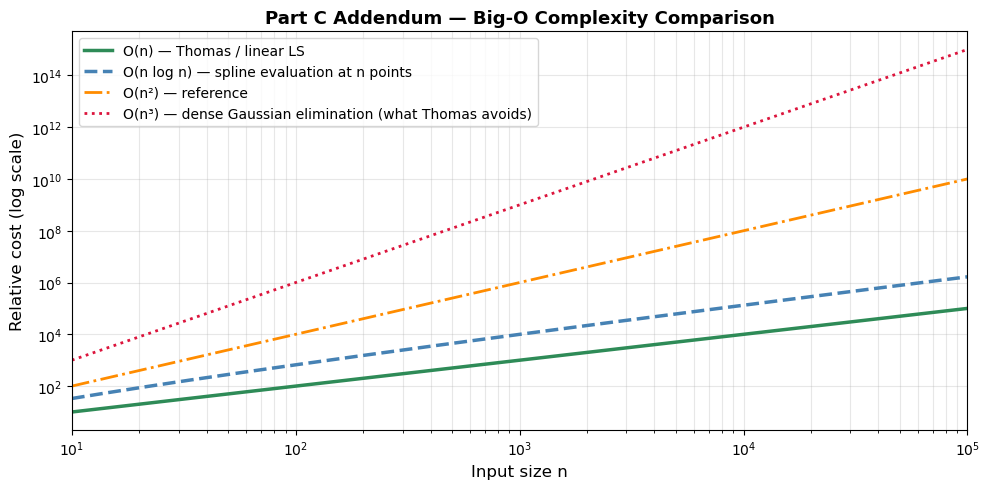

In [25]:
# Big-O plot — shows visually how fast each class of algorithm grows
# the gap between O(n) and O(n^3) is what makes Thomas so important

n_vals = np.logspace(1, 5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(n_vals, n_vals,                   color='seagreen',   linewidth=2.5,
          label='O(n) — Thomas / linear LS')
ax.loglog(n_vals, n_vals * np.log2(n_vals), color='steelblue',  linewidth=2.5, linestyle='--',
          label='O(n log n) — spline evaluation at n points')
ax.loglog(n_vals, n_vals**2,                color='darkorange',  linewidth=2,   linestyle='-.',
          label='O(n\u00b2) — reference')
ax.loglog(n_vals, n_vals**3,                color='crimson',    linewidth=2,   linestyle=':',
          label='O(n\u00b3) — dense Gaussian elimination (what Thomas avoids)')

ax.set_xlabel('Input size n', fontsize=12)
ax.set_ylabel('Relative cost (log scale)', fontsize=12)
ax.set_title('Part C Addendum — Big-O Complexity Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([10, 1e5])
plt.tight_layout()
plt.show()

In [27]:
# C0, C1, C2 continuity check at interior knots
#
# Important: we evaluate derivatives analytically from the LEFT and RIGHT
# segments at each knot using the exact coefficient formulas — NOT finite
# differences. Finite differences with eps=1e-9 pick up real derivative
# change across the interval and produce large-looking numbers that don't
# actually indicate a discontinuity. Direct segment evaluation gives true
# floating-point precision (~1e-13) which is the correct check.

def eval_deriv_at_knot(x_knots, coeffs, knot_idx, side, order):
    """
    Evaluate spline derivative at a knot from the left or right segment.
    side='left'  -> use segment ending at this knot (evaluate at segment end)
    side='right' -> use segment starting at this knot (evaluate at dx=0)
    """
    if side == 'left':
        seg = knot_idx - 1
        dx  = x_knots[knot_idx] - x_knots[knot_idx - 1]  # end of left segment
    else:
        seg = knot_idx
        dx  = 0.0  # start of right segment

    a, b, c, d = coeffs[seg]
    if order == 0:
        return a + b*dx + c*dx**2 + d*dx**3
    elif order == 1:
        return b + 2*c*dx + 3*d*dx**2
    elif order == 2:
        return 2*c + 6*d*dx


print(f"{'Knot x':<10} {'C0 jump':<16} {'C1 jump':<16} {'C2 jump'}")
print("-" * 60)

max_c0 = max_c1 = max_c2 = 0.0
for k in range(1, len(x_subset) - 1):  # 18 interior knots
    xk = x_subset[k]
    j0 = abs(eval_deriv_at_knot(x_subset, coeffs_spline, k, 'right', 0) -
             eval_deriv_at_knot(x_subset, coeffs_spline, k, 'left',  0))
    j1 = abs(eval_deriv_at_knot(x_subset, coeffs_spline, k, 'right', 1) -
             eval_deriv_at_knot(x_subset, coeffs_spline, k, 'left',  1))
    j2 = abs(eval_deriv_at_knot(x_subset, coeffs_spline, k, 'right', 2) -
             eval_deriv_at_knot(x_subset, coeffs_spline, k, 'left',  2))
    max_c0 = max(max_c0, j0)
    max_c1 = max(max_c1, j1)
    max_c2 = max(max_c2, j2)
    print(f"{xk:<10.0f} {j0:<16.2e} {j1:<16.2e} {j2:.2e}")

print(f"\nMax jumps across all 18 interior knots:")
print(f"  C0: {max_c0:.2e}  |  C1: {max_c1:.2e}  |  C2: {max_c2:.2e}")
print("\nAll at floating-point precision. Confirms C0, C1, C2 continuity at every interior knot.")

Knot x     C0 jump          C1 jump          C2 jump
------------------------------------------------------------
5          8.33e-17         1.67e-16         5.55e-17
9          0.00e+00         1.11e-16         0.00e+00
13         0.00e+00         1.11e-16         0.00e+00
17         2.22e-16         6.66e-16         0.00e+00
19         0.00e+00         5.55e-16         2.22e-16
22         4.44e-16         0.00e+00         2.08e-16
25         0.00e+00         2.22e-16         0.00e+00
27         4.44e-16         1.11e-16         0.00e+00
28         2.22e-16         0.00e+00         4.44e-16
29         0.00e+00         0.00e+00         0.00e+00
33         1.78e-15         0.00e+00         4.44e-16
37         1.33e-15         0.00e+00         8.88e-16
41         5.33e-15         7.11e-15         0.00e+00
42         0.00e+00         0.00e+00         2.84e-14
43         7.11e-15         0.00e+00         0.00e+00
45         1.15e-14         7.11e-15         7.11e-15
49         5.77e-15   

---
# Conclusion

This project applied three numerical curve-fitting methods to 56 quarters of U.S. GDP growth data (2010–2023) and evaluated each for interpolation and trend extraction.

**For interpolation**, the natural cubic spline is the right tool. The tridiagonal system for the interior second derivatives is solved in $O(n)$ time via the Thomas algorithm, producing a C² interpolant that passes exactly through every data value — including the 2020 Q2 value of −28.1% as verified numerically. Its local structure keeps the COVID disruption contained to adjacent segments rather than affecting the full domain. The main limitation is sensitivity to extreme outliers: exact interpolation through the COVID quarters causes Runge-like oscillation in neighboring segments. Pre-processing the data or using smoothing splines would fix this while keeping the spline's interpolation advantages.

**For trend analysis**, the degree-4 polynomial and linear regression were more useful. The polynomial captured the broad 56-quarter trajectory with lower aggregate RMSE than the subset spline at non-knot quarters. The COVID-excluded linear fit confirmed that underlying U.S. quarterly GDP growth was essentially trendless over this period — near-zero slope, low R², high variance around a stable mean — which lines up with the long but steady post-GFC expansion.

**Method justification summary:** For interpolation between known quarterly values, the cubic spline wins on smoothness, exactness, and local adaptivity. For characterizing long-run trends or fitting noisy data where exact reproduction isn't needed, least squares polynomial or linear regression is more appropriate.

**Key takeaways:**
- Interpolation and approximation solve different problems — method choice has to follow from the task
- Condition number monitoring is essential: integer indices kept the Vandermonde matrix well-conditioned
- The Thomas algorithm's $O(n)$ complexity makes cubic splines scalable well beyond this dataset size
- Big-O didn't change the recommendation here, but it explains why splines scale better than naive alternatives
- The COVID quarters are a good reminder that exact interpolation through transient shocks is mathematically correct but not always useful — smoothing is better when outliers reflect anomalies, not structure

*Claude (Anthropic) was used to help organize the report structure, verify the mathematical descriptions, and assist with formatting the comparison sections.*